Loading necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Reading the mapped.bed file and then assigning names to the columns in it for easy manipulation of data

In [2]:
columns = ['col1', 'chr1', 'start1', 'end1', 'name', 'score', 'strand1', 
           'chr2', 'start2', 'end2', 'id', 'size', 'strand2']
data = pd.read_csv('mapped.bed', sep='\t', header=None, names=columns)

Calculating centres and required values

In [3]:
data['C1'] = (data['start1'] + data['end1']) / 2
data['C2'] = (data['start2'] + data['end2']) / 2

X is the difference between C2 and C1 (the centres) and Y is the fragment length.

These metrics help in capturing essential biological information needed for visualization 

In [4]:
data['X'] = data['C2'] - data['C1']
data['X'] = data['X'].round().astype(int)

data['Y'] = data['end2'] - data['start2']
data['Y'] = data['Y'].astype(int)


Grouping by X and Y and then creating pivot table used for generating heatmap

In [5]:
result = data.groupby(['X', 'Y']).size().reset_index(name='Z')
pivot_table = result.pivot_table(values='Z', index='Y', columns='X', fill_value=0)

# Apply log transformation to better visualize the counts
pivot_table_log = np.log1p(pivot_table)  # log(1+x) to handle zeros
pivot_table_log=pivot_table_log.sort_index(ascending=False)

Plotting final graph

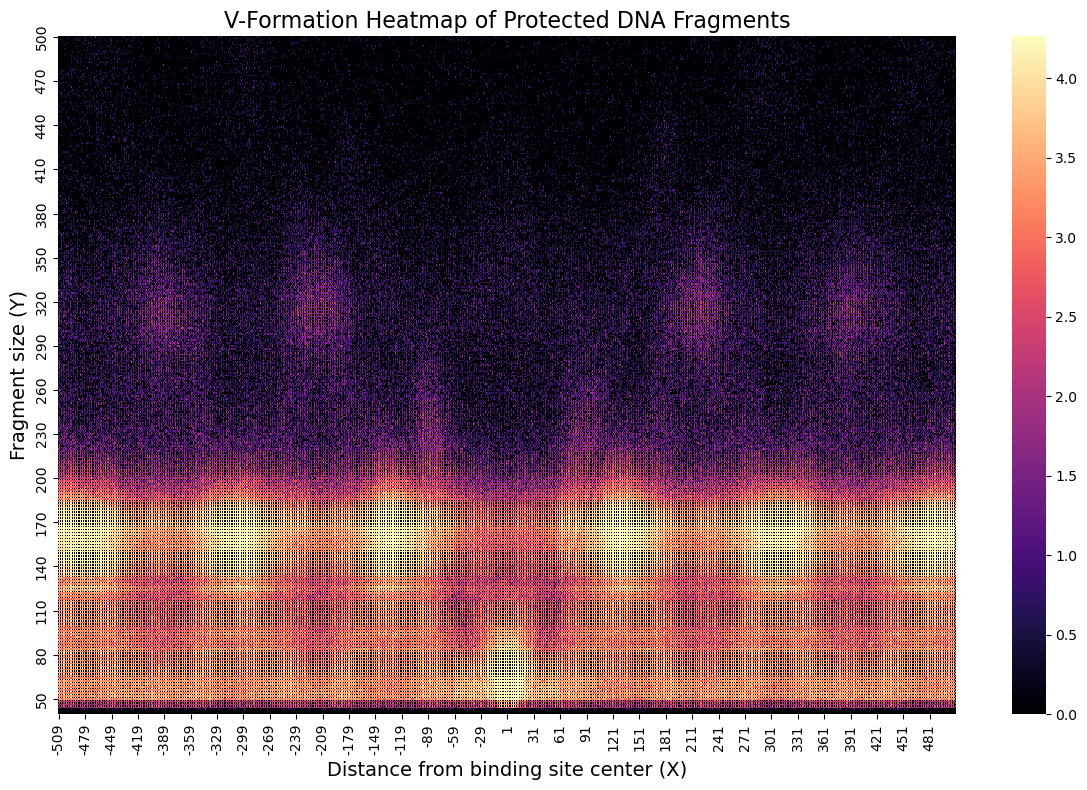

In [6]:
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table_log, cmap="magma",xticklabels=30,yticklabels=30, robust=True)
plt.title("V-Formation Heatmap of Protected DNA Fragments", fontsize=16)
plt.xlabel("Distance from binding site center (X)", fontsize=14)
plt.ylabel("Fragment size (Y)", fontsize=14)
plt.tight_layout()
plt.show()